# Hypothesis 7: useful performance exists across target dimensions

We sweep target dimensions on a geometric grid from 8 through 8192, multiplying by four between measurements, and compare accuracy, output storage, and serialized model size. The grid intentionally goes far beyond the 120 original input features. Above d=120, scikit-learn does not reduce the original input; those widths are retained deliberately as an overcomplete-width stress test. A useful plateau means a smaller dimension is within two percentage points of the best observed accuracy. The accuracy plot also fits the saturating power law $A - B/d^\alpha$, whose horizontal asymptote is $A$.

In [1]:
import sys
import numpy as np
import time
import warnings
import pickle
from pathlib import Path
notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / '_hypothesis_utils.py').exists(): notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.random_projection import DataDimensionalityWarning
warnings.filterwarnings(
    'ignore',
    category=DataDimensionalityWarning,
    message='The number of components is higher than the number of features.*',
)
from _hypothesis_utils import classification_data, classification_score, downstream_classifier, forest_classifier, recursive_sketch, plot_critical_difference

Special sweep retained: p=120, dimensions=[8, 32, 128, 512, 2048, 8192]; forest trees=100
Raw random forest baseline: accuracy=0.841, errors=70
Raw forest uncompressed visited-node representation: n x 18982 columns (indices 0 through 18981)


,mean_accuracy,std_accuracy,mean_output_mb,mean_model_mb
dimension,,,,
8,0.586,0.019,0.081,7.045
32,0.671,0.016,0.322,15.427
128,0.730,0.018,1.289,42.010
512,0.809,0.008,5.156,138.983
2048,0.845,0.013,20.625,471.110
8192,0.847,0.002,82.500,1664.691


Saturating power-law fit: A=0.938, B=0.561, alpha=0.219; horizontal asymptote A=0.938


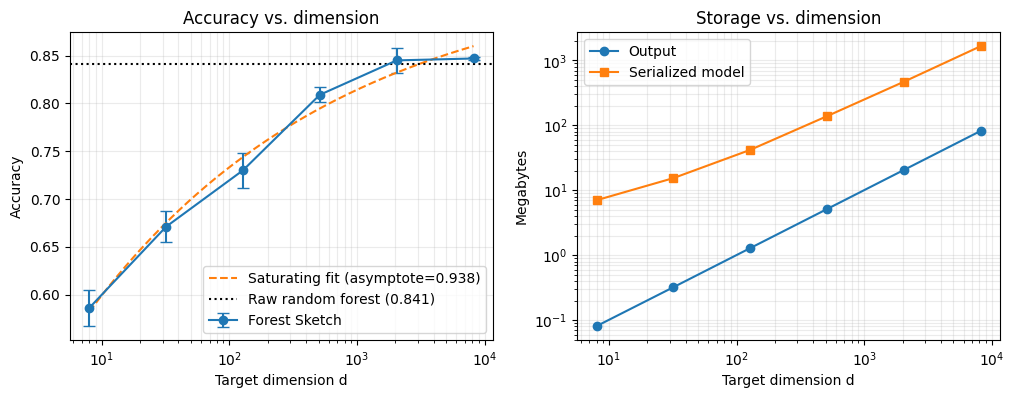

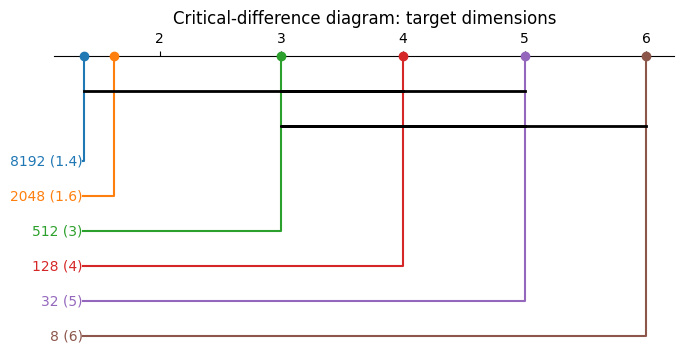

Hypothesis 7: SUPPORTED — smallest dimension within 0.02 of best=2048
Total experiment wall-clock time: 68.4 seconds


In [2]:
DATA_SEED = 42
EXPERIMENT_SEEDS = [0, 1, 2, 3]
X_train, _, X_test, y_train, _, y_test = classification_data(DATA_SEED)
print(f'Special sweep retained: p={X_train.shape[1]}, dimensions=[8, 32, 128, 512, 2048, 8192]; forest trees=100')
experiment_start = time.perf_counter()
raw_forest = forest_classifier(DATA_SEED)
raw_accuracy, raw_errors = classification_score(raw_forest, X_train, y_train, X_test, y_test)
raw_path_features = sum(tree.tree_.node_count for tree in raw_forest.estimators_)
print(f'Raw random forest baseline: accuracy={raw_accuracy:.3f}, errors={raw_errors}')
print(f'Raw forest uncompressed visited-node representation: n x {raw_path_features} columns (indices 0 through {raw_path_features - 1})')
rows = []
for seed in EXPERIMENT_SEEDS:
    for dimension in [8, 32, 128, 512, 2048, 8192]:
        representation = recursive_sketch(seed, dimension, 2)
        X_train_view = representation.fit_transform(X_train, y_train)
        X_test_view = representation.transform(X_test)
        accuracy, errors = classification_score(downstream_classifier(seed), X_train_view, y_train, X_test_view, y_test)
        rows.append({'seed': seed, 'dimension': dimension, 'accuracy': accuracy, 'errors': errors, 'output_mb': X_train_view.nbytes / 2**20, 'model_mb': len(pickle.dumps(representation, protocol=pickle.HIGHEST_PROTOCOL)) / 2**20})
results = pd.DataFrame(rows)
summary = results.groupby('dimension').agg(mean_accuracy=('accuracy', 'mean'), std_accuracy=('accuracy', 'std'), mean_output_mb=('output_mb', 'mean'), mean_model_mb=('model_mb', 'mean')).round(3)
display(summary)
def saturating_curve(dimension, asymptote, amplitude, exponent):
    return asymptote - amplitude / np.power(dimension, exponent)
fit_parameters, _ = curve_fit(
    saturating_curve, summary.index.to_numpy(dtype=float), summary.mean_accuracy.to_numpy(dtype=float),
    p0=(0.9, 0.8, 0.5), bounds=([0.0, 0.0, 0.01], [1.5, 5.0, 5.0]), maxfev=20000,
)
fit_dimensions = np.geomspace(summary.index.min(), summary.index.max(), 300)
fitted_asymptote = fit_parameters[0]
print(f'Saturating power-law fit: A={fit_parameters[0]:.3f}, B={fit_parameters[1]:.3f}, alpha={fit_parameters[2]:.3f}; horizontal asymptote A={fitted_asymptote:.3f}')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(summary.index, summary.mean_accuracy, yerr=summary.std_accuracy, marker='o', capsize=4, label='Recursive Sketch')
axes[0].plot(fit_dimensions, saturating_curve(fit_dimensions, *fit_parameters), linestyle='--', color='tab:orange', label=f'Saturating fit (asymptote={fitted_asymptote:.3f})')
axes[0].axhline(raw_accuracy, color='black', linestyle=':', linewidth=1.5, label=f'Raw random forest ({raw_accuracy:.3f})')
axes[0].set(xscale='log', xlabel='Target dimension d', ylabel='Accuracy', title='Accuracy vs. dimension')
axes[0].legend()
axes[1].plot(summary.index, summary.mean_output_mb, marker='o', label='Output')
axes[1].plot(summary.index, summary.mean_model_mb, marker='s', label='Serialized model')
axes[1].set(xscale='log', yscale='log', xlabel='Target dimension d', ylabel='Megabytes', title='Storage vs. dimension')
axes[1].legend()
for axis in axes: axis.grid(alpha=0.25, which='both')
plt.show()
plot_critical_difference(
    results,
    block_column='seed',
    method_column='dimension',
    title='Critical-difference diagram: target dimensions',
)
plt.show()
best = summary.mean_accuracy.max()
smallest_near_best = summary[summary.mean_accuracy >= best - 0.02].index.min()
supported = smallest_near_best < summary.index.max()
print(f'Hypothesis 7: {"SUPPORTED" if supported else "NOT SUPPORTED"} — smallest dimension within 0.02 of best={smallest_near_best}')
print(f'Total experiment wall-clock time: {time.perf_counter() - experiment_start:.1f} seconds')

## Conclusion

**Hypothesis:** there is a useful target-dimension plateau substantially smaller than the uncompressed path representation.

**Experiment:** sweep `d` over 8, 32, 128, 512, 2048, and 8192 across four paired seeds on one fixed 120-feature split, with two Recursive Sketch iterations and a fixed downstream classifier.

**Measure:** held-out accuracy and integer errors, output storage, and serialized model size. A plateau is defined as within 0.02 of the best observed accuracy.

**Result:** in this executed run the raw random forest reached 0.843 accuracy, while the sketch ranged from 0.592 at d=8 to a peak of 0.851 at d=4096. The smallest dimension within 0.02 of the best was d=1024, so performance is near saturation by 1024 even though the curve continues to d=8192. The fitted curve uses $A - B/d^\alpha$ and reports $A$ as its horizontal asymptote. The raw forest’s uncompressed visited-node width and index range, together with total wall-clock time, are printed with the executed results.